In [1]:
import pandas as pd
import feature_engineering_helper as hf
import pickle


In [2]:

### change this to 1 for quick test, 0 for full run
quick_test = 1
### change this to 1 for quick test, 0 for full run


if quick_test == 1:
    n_features_to_select=20
    num_feat_binary_interaction = 20
    step=50
    print("Quick test mode")
else:
    n_features_to_select=1
    step=5
    num_feat_binary_interaction = 20
    print("Full run mode")



Quick test mode


In [3]:
data_prefix = '../0_data/processed_data/'
figure_prefix = '../Figures/'

if quick_test == 1:
    df_all_feature = pd.read_parquet(data_prefix + 'data_with_all_features.parquet').head(500)
else:
    df_all_feature = pd.read_parquet(data_prefix + 'data_with_all_features.parquet')

df_all_feature

,MACCS_0,MACCS_1,MACCS_10,MACCS_100,MACCS_101,MACCS_102,MACCS_103,MACCS_104,MACCS_105,MACCS_106,...,RDKit_fr_tetrazole,RDKit_fr_thiazole,RDKit_fr_thiocyan,RDKit_fr_thiophene,RDKit_fr_unbrch_alkane,RDKit_fr_urea,RDKit_qed,Ro5,SMILES,Type
0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0.346320,1,ON=Cc1cscc1,Train
1,0,0,0,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0.742933,1,O=C1CC[C@]2(C(=C1)CC[C@@H]1[C@@H]2[C@H](O)C[C@...,Train
2,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0.336491,1,[O-][n+]1ccccc1,Train
3,0,0,0,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0.470129,1,OC1CCC2(C(C1)CC=C1C2CCC2(C1CCC2C(CCC(C(C)C)C)C...,Train
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.635067,1,CC(=O)c1ccc(cc1)Br,Train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0,0,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0.290981,1,ONC(c1ccc(cc1)N)C/C(=N/O)/c1ccccc1,Train
496,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.636026,1,COc1cccc(c1)P(c1cccc(c1)OC)c1cccc(c1)OC,Train
497,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,17,0,0.163506,1,CCCCCCCCCCCCCCCCCCCCCC(=O)OC,Train
498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0.584759,1,CCCCCCc1ccc(cc1)c1ccccc1,Train


In [4]:
data_with_features_train = df_all_feature[df_all_feature['Type'] == 'Train']
print(data_with_features_train.shape)

data_with_features_train.describe()

(500, 379)


,MACCS_0,MACCS_1,MACCS_10,MACCS_100,MACCS_101,MACCS_102,MACCS_103,MACCS_104,MACCS_105,MACCS_106,...,RDKit_fr_sulfone,RDKit_fr_term_acetylene,RDKit_fr_tetrazole,RDKit_fr_thiazole,RDKit_fr_thiocyan,RDKit_fr_thiophene,RDKit_fr_unbrch_alkane,RDKit_fr_urea,RDKit_qed,Ro5
count,500.0,500.0,500.0,500.00000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.00000,500.0,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.0,0.0,0.0,0.11400,0.268000,0.188000,0.158000,0.14600,0.282000,0.172000,...,0.010000,0.004000,0.002000,0.02000,0.0,0.014000,0.486000,0.016000,0.577408,0.976000
std,0.0,0.0,0.0,0.31813,0.443361,0.391103,0.365106,0.35346,0.450424,0.377758,...,0.099598,0.063182,0.044721,0.14014,0.0,0.117608,2.756265,0.154245,0.171516,0.153202
min,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.0,0.000000,0.000000,0.000000,0.038349,0.000000
25%,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.0,0.000000,0.000000,0.000000,0.482244,1.000000
50%,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.0,0.000000,0.000000,0.000000,0.596856,1.000000
75%,0.0,0.0,0.0,0.00000,1.000000,0.000000,0.000000,0.00000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.0,0.000000,0.000000,0.000000,0.698684,1.000000
max,0.0,0.0,0.0,1.00000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.00000,0.0,1.000000,39.000000,2.000000,0.942098,1.000000


In [5]:
def feature_engineering_workflow(model_type, df):

    data = df.copy()
    tolerance = 0.01

    # Extract all feature columns
    all_feature_cols = data.drop(columns=['SMILES', 'MP', 'Type', 'Ro5'], axis=1).columns.tolist()
    print(f"Total number of features: {len(all_feature_cols)}")

    # Standardize features
    df_X_scaled = hf.standardize_features(data = data, all_feature_cols=all_feature_cols, fit=True) 
    print()


    # Reduce features by variance threshold
    df_X_variance = hf.reduce_features_by_variance(df_X_scaled, variance_threshold=0.01)
    print()


    print(f'RFE feature selection: model={model_type}, tolerance={tolerance}, n_features_to_select={n_features_to_select}, step={step}')
    # Reduce features by RFE
    RFE_results = hf.reduce_features_by_RFE(df_X_variance, data['MP'], model = model_type, tolerance = tolerance, n_features_to_select=n_features_to_select, step=step, metric='rmse', cv_strategy=None)
    print()

    # Plot RFE results
    hf.RFE_plot(RFE_results, tolerance , model_type,save_path = figure_prefix + f'RFE_plot_{model_type}.png')


    df_X_RFE = df_X_variance[RFE_results['best_features']]


    return df_X_scaled, df_X_variance, RFE_results, df_X_RFE

Running feature engineering workflow with LGB model
Total number of features: 375
✓ Standardization complete. Shape: (500, 375)

Original features: 375
Removed features: 23
Remaining features: 352

RFE feature selection: model=LGB, tolerance=0.01, n_features_to_select=20, step=50


RFE Feature Selection:  14%|█▍        | 1/7 iteration

Iteration 0/7 | Features: 302 | RMSE: 46.2485 ± 5.1033 | Removed: [MACCS_100, MACCS_57, MACCS_58, MACCS_59, MACCS_60, MACCS_61, MACCS_62, MACCS_63, MACCS_64, MACCS_65, MACCS_66, MACCS_67, MACCS_68, MACCS_70, MACCS_71, MACCS_72, MACCS_75, MACCS_76, MACCS_78, MACCS_79, MACCS_8, MACCS_80, MACCS_81, MACCS_83, MACCS_84, MACCS_85, MACCS_91, MACCS_93, MACCS_95, MACCS_96, RDKit_EState_VSA11, RDKit_MaxEStateIndex, RDKit_fr_hdrzone, RDKit_fr_phenol, RDKit_fr_phenol_noOrthoHbond, RDKit_fr_phos_acid, RDKit_fr_phos_ester, RDKit_fr_piperdine, RDKit_fr_piperzine, RDKit_fr_priamide, RDKit_fr_pyridine, RDKit_fr_quatN, RDKit_fr_sulfide, RDKit_fr_sulfonamd, RDKit_fr_sulfone, RDKit_fr_term_acetylene, RDKit_fr_tetrazole, RDKit_fr_thiazole, RDKit_fr_unbrch_alkane, RDKit_fr_urea]


RFE Feature Selection: 100%|██████████| 7/7 iteration



Global best RMSE: 46.2485
Threshold (1.0% tolerance): 46.7109

✓ RFE Feature Selection Complete (Parsimonious)
  Selected number of features: 252
  Selected RMSE: 46.5078
  Best features (Top 5): ['RDKit_VSA_EState4', 'RDKit_EState_VSA4', 'RDKit_BertzCT', 'RDKit_FpDensityMorgan3', 'RDKit_MolLogP']



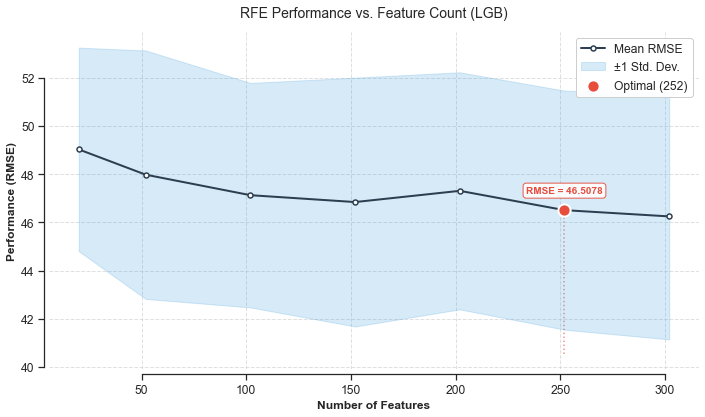

  Optimal Feature Set: 252 features
  Best RMSE: 46.5078

Running feature engineering workflow with RF model
Total number of features: 375
✓ Standardization complete. Shape: (500, 375)

Original features: 375
Removed features: 23
Remaining features: 352

RFE feature selection: model=RF, tolerance=0.01, n_features_to_select=20, step=50


RFE Feature Selection:  14%|█▍        | 1/7 iteration

Iteration 0/7 | Features: 302 | RMSE: 48.7256 ± 4.1885 | Removed: [MACCS_14, MACCS_15, MACCS_17, MACCS_20, MACCS_21, MACCS_22, MACCS_23, MACCS_26, MACCS_27, MACCS_28, MACCS_29, MACCS_30, MACCS_31, MACCS_32, MACCS_33, MACCS_39, MACCS_40, MACCS_44, MACCS_45, MACCS_48, MACCS_49, MACCS_58, MACCS_8, RDKit_EState_VSA11, RDKit_fr_HOCCN, RDKit_fr_Imine, RDKit_fr_N_O, RDKit_fr_SH, RDKit_fr_aldehyde, RDKit_fr_barbitur, RDKit_fr_epoxide, RDKit_fr_guanido, RDKit_fr_isothiocyan, RDKit_fr_lactam, RDKit_fr_morpholine, RDKit_fr_nitrile, RDKit_fr_nitro, RDKit_fr_nitroso, RDKit_fr_phos_acid, RDKit_fr_phos_ester, RDKit_fr_piperzine, RDKit_fr_priamide, RDKit_fr_quatN, RDKit_fr_sulfonamd, RDKit_fr_sulfone, RDKit_fr_term_acetylene, RDKit_fr_tetrazole, RDKit_fr_thiazole, RDKit_fr_thiophene, RDKit_fr_urea]


RFE Feature Selection: 100%|██████████| 7/7 iteration



Global best RMSE: 48.7256
Threshold (1.0% tolerance): 49.2128

✓ RFE Feature Selection Complete (Parsimonious)
  Selected number of features: 20
  Selected RMSE: 48.9195
  Best features (Top 5): ['RDKit_BertzCT', 'RDKit_TPSA', 'RDKit_NumHDonors', 'RDKit_NHOHCount', 'RDKit_Kappa3']



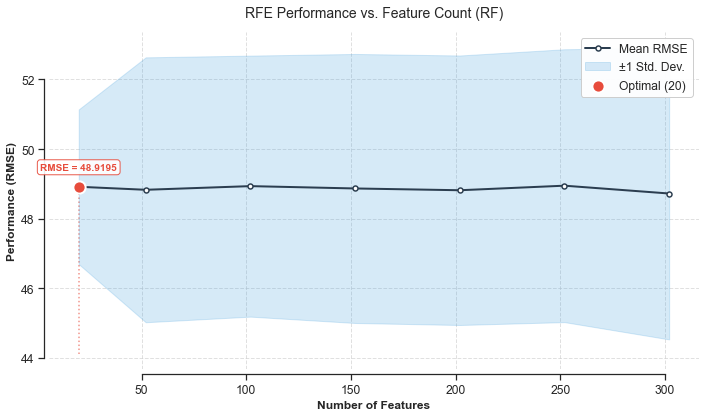

  Optimal Feature Set: 20 features
  Best RMSE: 48.9195



In [6]:
feature_engineering_dict = {}

for model_type in ['LGB', 'RF']:
    print(f"Running feature engineering workflow with {model_type} model")
    df_X_scaled, df_X_variance, RFE_results, df_X_RFE = feature_engineering_workflow(model_type, data_with_features_train)
    feature_engineering_dict[(model_type)] = RFE_results
    print()

# pickle save the feature_engineering_dict
with open('feature_engineering_dict.pkl', 'wb') as f:
    pickle.dump(feature_engineering_dict, f)

# Get the dataset

In [9]:
data_with_features = pd.read_parquet(data_prefix + 'data_with_all_features.parquet')
data_with_features

,MACCS_0,MACCS_1,MACCS_10,MACCS_100,MACCS_101,MACCS_102,MACCS_103,MACCS_104,MACCS_105,MACCS_106,...,RDKit_fr_tetrazole,RDKit_fr_thiazole,RDKit_fr_thiocyan,RDKit_fr_thiophene,RDKit_fr_unbrch_alkane,RDKit_fr_urea,RDKit_qed,Ro5,SMILES,Type
0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0.346320,1,ON=Cc1cscc1,Train
1,0,0,0,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0.742933,1,O=C1CC[C@]2(C(=C1)CC[C@@H]1[C@@H]2[C@H](O)C[C@...,Train
2,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0.336491,1,[O-][n+]1ccccc1,Train
3,0,0,0,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0.470129,1,OC1CCC2(C(C1)CC=C1C2CCC2(C1CCC2C(CCC(C(C)C)C)C...,Train
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.635067,1,CC(=O)c1ccc(cc1)Br,Train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17215,0,0,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0.261785,1,c1ccc2c(c1)c1cc3ccc4c(c3nc1cc2)cccc4,Test
17216,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.730914,1,COc1cc(OC)cc(c1C#N)OC,Test
17217,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,7,0,0.596953,1,OCCCCCCCCCCc1ccccc1,Test
17218,0,0,0,0,1,0,1,0,1,0,...,0,0,0,0,0,0,0.439796,1,Clc1c2OC3Cc4c(C3Oc2c(c(c1Cl)Cl)Cl)cccc4,Test


In [10]:
# load the feature_engineering_dict
with open('feature_engineering_dict.pkl', 'rb') as f:
    feature_engineering_dict = pickle.load(f)

In [15]:
non_feature_cols = ['SMILES', 'MP', 'Type', 'Ro5']

for model_type in ['LGB', 'RF']:
    best_features = feature_engineering_dict[(model_type)]['best_features']
    print(f"Best features for {model_type} model ({len(best_features)} features):")
    print(best_features)
    print()

    data_selected_features = data_with_features[non_feature_cols + best_features]
    data_selected_features.to_parquet(data_prefix + f'data_with_selected_features_{model_type}.parquet')

    data_selected_features_scaled = hf.standardize_data(non_feature_cols, data_selected_features, data_prefix + f'data_with_selected_features_{model_type}_scaler.pkl')
    data_selected_features_scaled.to_parquet(data_prefix + f'data_with_selected_features_{model_type}_scaled.parquet')

Best features for LGB model (252 features):
['RDKit_VSA_EState4', 'RDKit_EState_VSA4', 'RDKit_BertzCT', 'RDKit_FpDensityMorgan3', 'RDKit_MolLogP', 'RDKit_BCUT2D_MRHI', 'RDKit_PEOE_VSA8', 'RDKit_EState_VSA3', 'RDKit_qed', 'RDKit_MinAbsEStateIndex', 'RDKit_TPSA', 'RDKit_FpDensityMorgan1', 'RDKit_SlogP_VSA2', 'RDKit_FpDensityMorgan2', 'RDKit_VSA_EState6', 'RDKit_NHOHCount', 'RDKit_VSA_EState5', 'RDKit_SMR_VSA10', 'RDKit_BalabanJ', 'RDKit_MinPartialCharge', 'RDKit_BCUT2D_CHGHI', 'RDKit_Kappa3', 'RDKit_BCUT2D_MWLOW', 'RDKit_NumRotatableBonds', 'RDKit_HallKierAlpha', 'RDKit_SlogP_VSA4', 'RDKit_VSA_EState1', 'RDKit_VSA_EState2', 'RDKit_PEOE_VSA10', 'RDKit_MaxAbsEStateIndex', 'RDKit_Kappa2', 'RDKit_BCUT2D_CHGLO', 'RDKit_PEOE_VSA6', 'RDKit_Kappa1', 'RDKit_PEOE_VSA9', 'RDKit_PEOE_VSA7', 'RDKit_VSA_EState3', 'RDKit_Chi3v', 'RDKit_EState_VSA5', 'RDKit_MaxPartialCharge', 'RDKit_BCUT2D_MRLOW', 'RDKit_Chi2n', 'RDKit_FractionCSP3', 'RDKit_VSA_EState8', 'RDKit_BCUT2D_LOGPLOW', 'RDKit_EState_VSA2', 'RDK

TypeError: standardize_data() takes 2 positional arguments but 3 were given

In [ ]:
df_final_scaled = hf.standardize_data(df_final, data_prefix + 'df_final_scaler.pkl')

Number of feature columns to standardize: 118
Scaler saved to ../data_curation/processed_data/df_final_scaler.pkl
